In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df=pd.read_excel('Telco_customer_churn.xlsx')

#Assignment 1

In [ ]:
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.dtypes

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [ ]:
df.shape

(7043, 33)

##1.Detecting missing values

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


Detecting duplicate values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


In [ ]:
df['Churn Reason'].unique()

array(['Competitor made better offer', 'Moved',
       'Competitor had better devices',
       'Competitor offered higher download speeds',
       'Competitor offered more data', 'Price too high',
       'Product dissatisfaction', 'Service dissatisfaction',
       'Lack of self-service on Website', 'Network reliability',
       'Limited range of services',
       'Lack of affordable download/upload speed',
       'Long distance charges', 'Extra data charges', "Don't know",
       'Poor expertise of online support',
       'Poor expertise of phone support', 'Attitude of service provider',
       'Attitude of support person', 'Deceased', nan], dtype=object)

##2. Dropping unwanted columns

In [ ]:
df = df.drop(columns=['CustomerID', 'Country', 'State', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label'])

In [ ]:
df.columns

Index(['Count', 'City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')

City : ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
Gender : ['Male' 'Female']
Senior Citizen : ['No' 'Yes']
Partner : ['No' 'Yes']
Dependents : ['No' 'Yes']
Phone Service : ['Yes' 'No']
Multiple Lines : ['No' 'Yes' 'No phone service']
Internet Service : ['DSL' 'Fiber optic' 'No']
Online Security : ['Yes' 'No' 'No internet service']
Online Backup : ['Yes' 'No' 'No internet service']
Device Protection : ['No' 'Yes' 'No internet service']
Tech Support : ['No' 'Yes' 'No internet service']
Streaming TV : ['No' 'Yes' 'No internet service']
Streaming Movies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'Two year' 'One year']
Paperless Billing : ['Yes' 'No']
Payment Method : ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Total Charges : [108.15 151.65 820.5 ... 7362.9 346.45 6844.5]
Churn Reason : ['Competitor made better offer' 'Moved' 'Competitor had better devices'
 'Competitor 

##3. Outlier Detection

In [ ]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce").fillna(0)
columns = ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Score", "CLTV"]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"{col}: {len(outliers)} outliers found")

    # Treatment: cap outliers to the lower/upper limit instead of removing them
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)


df.to_excel("Telco_customer_churn_cleaned.xlsx", index=False)
print("Done! Cleaned file saved.")


Tenure Months: 0 outliers found
Monthly Charges: 0 outliers found
Total Charges: 0 outliers found
Churn Score: 0 outliers found
CLTV: 0 outliers found
Done! Cleaned file saved.


##4.Categorical Data to numerical

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Group columns explicitly by logical type
binary_cols = ['Gender', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Senior Citizen']
ordinal_cols = ['Contract']
nominal_cols = [
    'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Payment Method'
]

contract_order = [['Month-to-month', 'One year', 'Two year']]
preprocessor = ColumnTransformer(
    transformers=[
        # Map binary columns to 0/1
        ('binary', OrdinalEncoder(), binary_cols),

        # Preserve specific order for ordinal features
        ('ordinal', OrdinalEncoder(categories=contract_order), ordinal_cols),

        # One-Hot Encode multi-class nominals (dropping first column to reduce multi-collinearity)
        ('nominal', OneHotEncoder(drop='first', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough'
)
encoded_array = preprocessor.fit_transform(df)

# Use get_feature_names_out() to get all column names correctly
encoded_cols = preprocessor.get_feature_names_out()

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols)

In [ ]:
encoded_df.head()

,binary__Gender,binary__Partner,binary__Dependents,binary__Phone Service,binary__Paperless Billing,binary__Senior Citizen,ordinal__Contract,nominal__Multiple Lines_No phone service,nominal__Multiple Lines_Yes,nominal__Internet Service_Fiber optic,...,nominal__Payment Method_Mailed check,remainder__Count,remainder__City,remainder__Tenure Months,remainder__Monthly Charges,remainder__Total Charges,remainder__Churn Value,remainder__Churn Score,remainder__CLTV,remainder__Churn Reason
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1,Los Angeles,2,53.85,108.15,1,86,3239,Competitor made better offer
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1,Los Angeles,2,70.7,151.65,1,67,2701,Moved
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1,Los Angeles,8,99.65,820.5,1,86,5372,Moved
3,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1,Los Angeles,28,104.8,3046.05,1,84,5003,Moved
4,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1,Los Angeles,49,103.7,5036.3,1,89,5340,Competitor had better devices


##5. Plot Distributions

In [ ]:
df.describe()

,Count,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


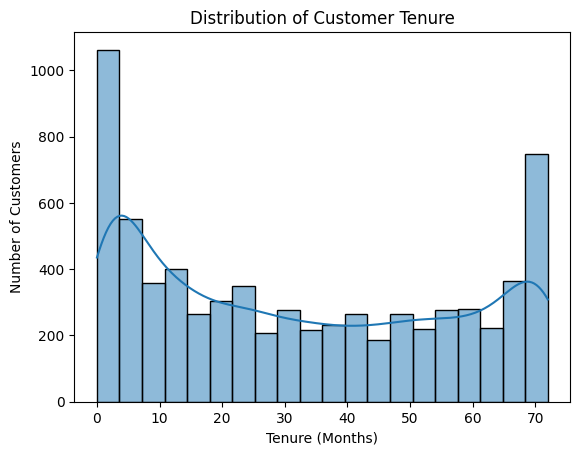

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Tenure Months'], bins=20, kde=True)
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

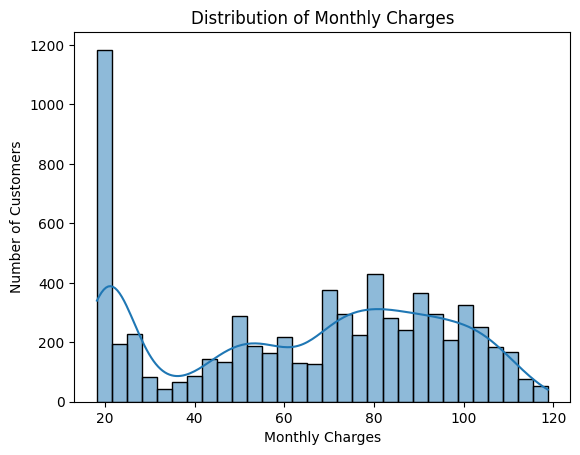

In [ ]:
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

##6.Analysis using Correlation

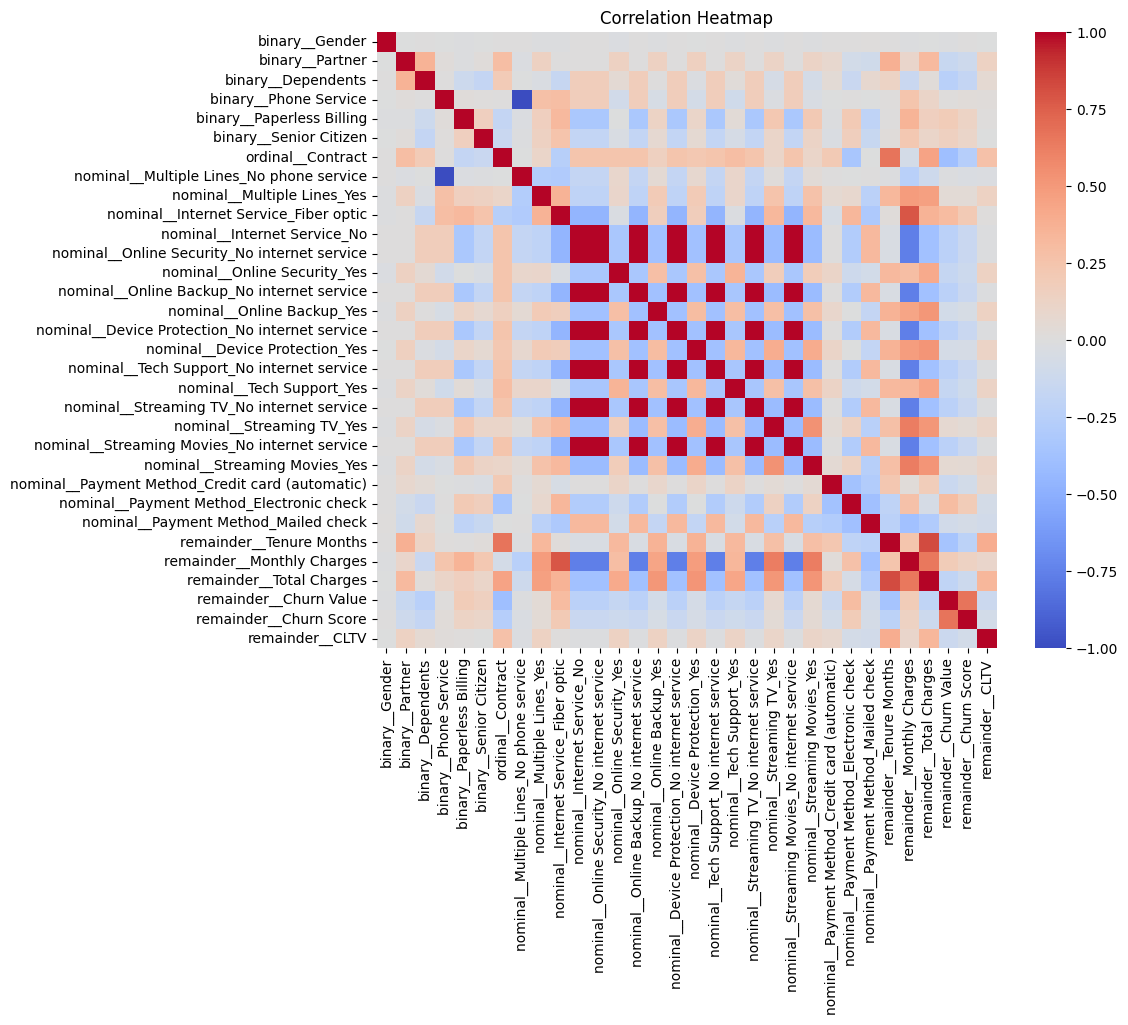

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
corr_matrix = encoded_df.drop(columns=['remainder__City', 'remainder__Churn Reason', 'remainder__Count']).corr()
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
churn_corr = encoded_df.drop(columns=['remainder__City', 'remainder__Churn Reason', 'remainder__Count']).corr()['remainder__Churn Value'].sort_values(
    ascending=False
)

churn_corr = churn_corr.drop('remainder__Churn Value')

print("Most positively correlated with Churn:")
print(churn_corr.head(10))

print("\nMost negatively correlated with Churn:")
print(churn_corr.tail(10))

Most positively correlated with Churn:
remainder__Churn Score                      0.664897
nominal__Internet Service_Fiber optic       0.308020
nominal__Payment Method_Electronic check    0.301919
remainder__Monthly Charges                  0.193356
binary__Paperless Billing                   0.191825
binary__Senior Citizen                      0.150889
nominal__Streaming TV_Yes                   0.063228
nominal__Streaming Movies_Yes               0.061382
nominal__Multiple Lines_Yes                 0.040102
binary__Phone Service                       0.011942
Name: remainder__Churn Value, dtype: float64

Most negatively correlated with Churn:
nominal__Internet Service_No                     -0.227890
nominal__Online Security_No internet service     -0.227890
nominal__Streaming Movies_No internet service    -0.227890
nominal__Streaming TV_No internet service        -0.227890
nominal__Device Protection_No internet service   -0.227890
nominal__Online Backup_No internet service       -0

#7.Feature Selection

### 7.1 Build the modeling table (drop IDs, constants & leakage)


In [ ]:
leak_or_useless = [
    'remainder__Count',
    'remainder__City',
    'remainder__Churn Score',
    'remainder__CLTV',
    'remainder__Churn Reason'
]

model_df = encoded_df.drop(columns=leak_or_useless).copy()

target_col = 'remainder__Churn Value'
X = model_df.drop(columns=[target_col])
y = model_df[target_col].astype(int)

print(X.shape, y.shape)
X.head()

(7043, 29) (7043,)


,binary__Gender,binary__Partner,binary__Dependents,binary__Phone Service,binary__Paperless Billing,binary__Senior Citizen,ordinal__Contract,nominal__Multiple Lines_No phone service,nominal__Multiple Lines_Yes,nominal__Internet Service_Fiber optic,...,nominal__Streaming TV_No internet service,nominal__Streaming TV_Yes,nominal__Streaming Movies_No internet service,nominal__Streaming Movies_Yes,nominal__Payment Method_Credit card (automatic),nominal__Payment Method_Electronic check,nominal__Payment Method_Mailed check,remainder__Tenure Months,remainder__Monthly Charges,remainder__Total Charges
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,53.85,108.15
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2,70.7,151.65
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,8,99.65,820.5
3,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,28,104.8,3046.05
4,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,49,103.7,5036.3


### 7.2 Filter method 1 — remove (near) zero-variance features


In [ ]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)   # drop features with variance < 0.01
vt.fit(X)

low_var_cols = X.columns[~vt.get_support()]
print("Low-variance columns dropped:", list(low_var_cols))

X = X.loc[:, vt.get_support()]
X.shape

Low-variance columns dropped: []


(7043, 29)

### 7.3 Filter method 2 — remove highly correlated (redundant) features


In [ ]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Highly correlated columns dropped:", to_drop)

X = X.drop(columns=to_drop)
X.shape

Highly correlated columns dropped: ['nominal__Multiple Lines_No phone service', 'nominal__Online Security_No internet service', 'nominal__Online Backup_No internet service', 'nominal__Device Protection_No internet service', 'nominal__Tech Support_No internet service', 'nominal__Streaming TV_No internet service', 'nominal__Streaming Movies_No internet service']


(7043, 22)

### 7.4 Filter method 3 — univariate association with the target


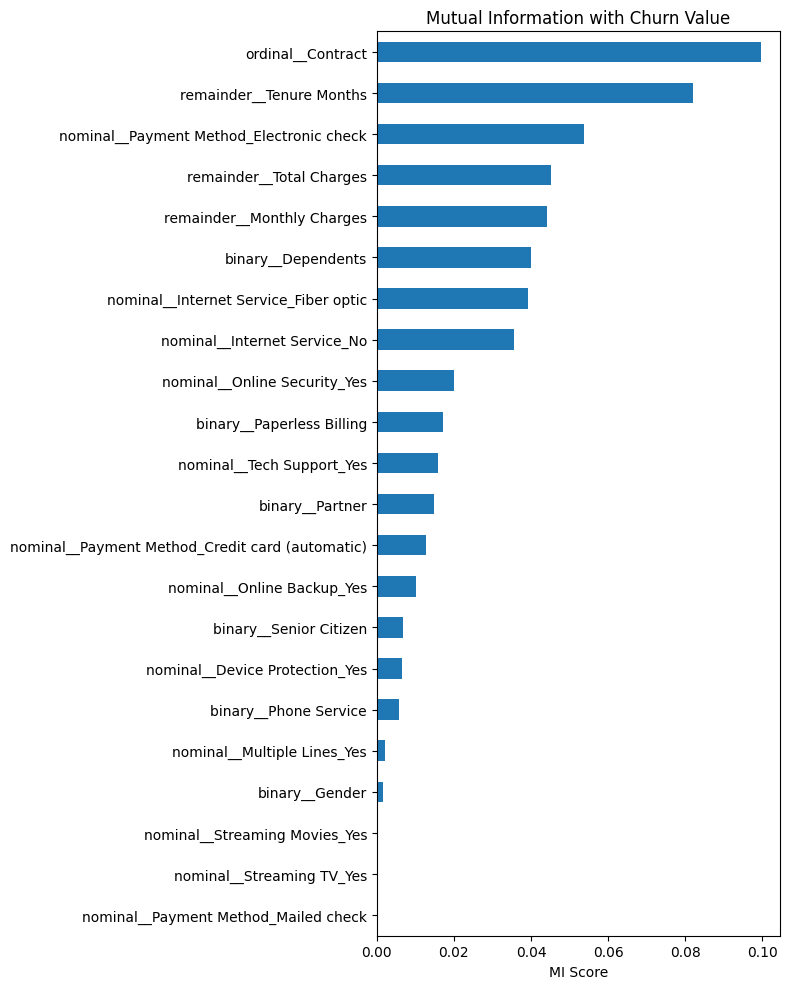

,0
ordinal__Contract,0.099588
remainder__Tenure Months,0.081961
nominal__Payment Method_Electronic check,0.053716
remainder__Total Charges,0.045283
remainder__Monthly Charges,0.044258
binary__Dependents,0.040036
nominal__Internet Service_Fiber optic,0.039186
nominal__Internet Service_No,0.035528
nominal__Online Security_Yes,0.020123
binary__Paperless Billing,0.017230


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
mi_series.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Mutual Information with Churn Value')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

mi_series.head(15)

### 7.5 Embedded method — Random Forest feature importance


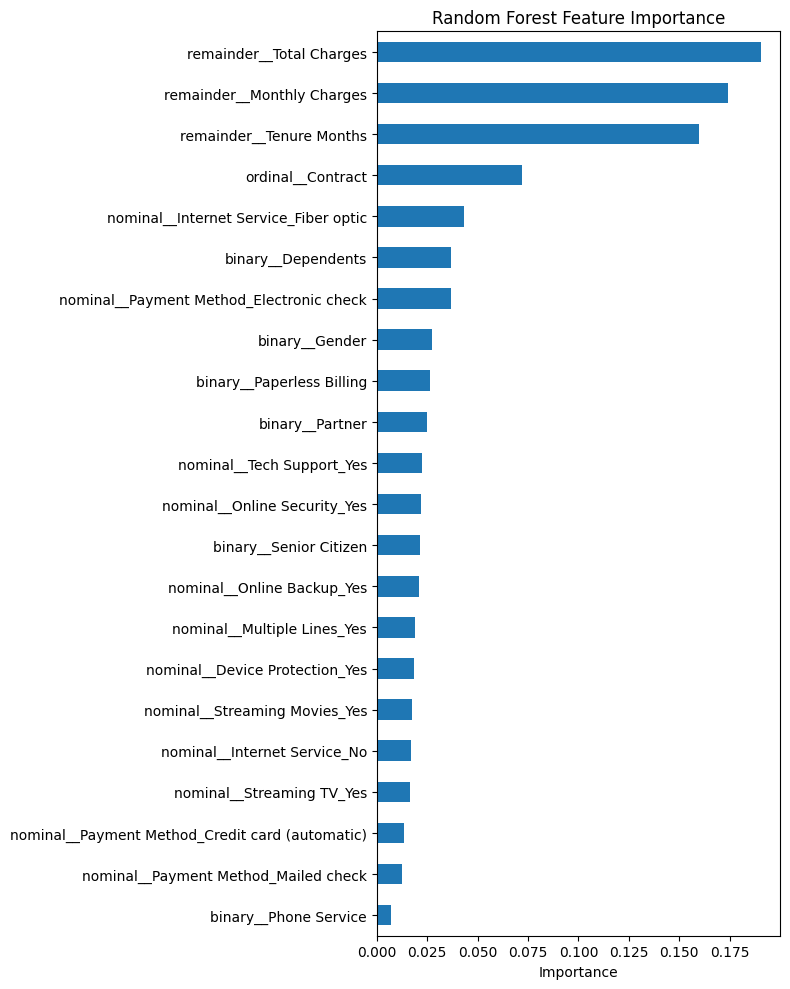

,0
remainder__Total Charges,0.190375
remainder__Monthly Charges,0.174022
remainder__Tenure Months,0.159889
ordinal__Contract,0.071826
nominal__Internet Service_Fiber optic,0.043155
binary__Dependents,0.036989
nominal__Payment Method_Electronic check,0.036672
binary__Gender,0.027408
binary__Paperless Billing,0.026420
binary__Partner,0.025104


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
rf_importance.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

rf_importance.head(15)

### 7.6 Wrapper method — Recursive Feature Elimination (RFE)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler

X_scaled_for_rfe = StandardScaler().fit_transform(X)

rfe_estimator = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=15)
rfe.fit(X_scaled_for_rfe, y)

selected_features = X.columns[rfe.support_]
print("RFE-selected features:")
print(list(selected_features))

RFE-selected features:
['binary__Partner', 'binary__Dependents', 'binary__Paperless Billing', 'ordinal__Contract', 'nominal__Multiple Lines_Yes', 'nominal__Internet Service_Fiber optic', 'nominal__Internet Service_No', 'nominal__Online Security_Yes', 'nominal__Tech Support_Yes', 'nominal__Streaming TV_Yes', 'nominal__Streaming Movies_Yes', 'nominal__Payment Method_Electronic check', 'remainder__Tenure Months', 'remainder__Monthly Charges', 'remainder__Total Charges']


### 7.7 Final selected feature set


In [ ]:
top_mi = set(mi_series.head(15).index)
top_rf = set(rf_importance.head(15).index)
top_rfe = set(selected_features)

final_features = sorted(top_mi | top_rf | top_rfe)
print(f"{len(final_features)} features selected:")
print(final_features)

X_selected = X[final_features]

19 features selected:
['binary__Dependents', 'binary__Gender', 'binary__Paperless Billing', 'binary__Partner', 'binary__Senior Citizen', 'nominal__Internet Service_Fiber optic', 'nominal__Internet Service_No', 'nominal__Multiple Lines_Yes', 'nominal__Online Backup_Yes', 'nominal__Online Security_Yes', 'nominal__Payment Method_Credit card (automatic)', 'nominal__Payment Method_Electronic check', 'nominal__Streaming Movies_Yes', 'nominal__Streaming TV_Yes', 'nominal__Tech Support_Yes', 'ordinal__Contract', 'remainder__Monthly Charges', 'remainder__Tenure Months', 'remainder__Total Charges']


## 8. Dimensionality Reduction with PCA



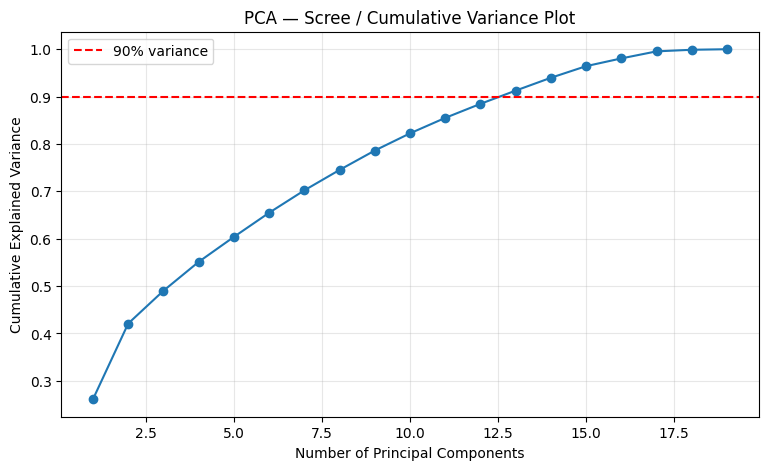

Components needed to reach 90% variance: 13 (out of 19 original features)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Scree / Cumulative Variance Plot')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

n_components_90 = np.argmax(cum_explained_var >= 0.90) + 1
print(f"Components needed to reach 90% variance: {n_components_90} (out of {X_selected.shape[1]} original features)")

### 8.1 Transform the data using the chosen number of components

In [ ]:
pca = PCA(n_components=n_components_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_cols = [f'PC{i+1}' for i in range(n_components_90)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols)

print(f"Reduced from {X_selected.shape[1]} features to {n_components_90} components")
X_pca_df.head()

Reduced from 19 features to 13 components


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-1.253616,-0.720275,-2.180723,-0.372811,0.864020,0.721365,1.230550,0.723049,1.305475,0.476903,-0.949293,-0.831989,-0.849123
1,-1.420136,-2.191949,0.454884,-1.480468,-1.151173,1.133263,-0.392548,0.463296,0.421756,-0.084555,0.151070,-0.640181,1.169786
2,0.887633,-2.499417,1.139219,-1.214227,-1.063225,0.648032,-1.934581,0.223204,-0.424312,-0.370551,0.237909,-1.643206,0.895311
3,2.278343,-1.208343,1.327531,-2.038609,-1.062683,0.771061,-1.524547,-0.345953,-0.381128,-0.903377,1.491129,0.058579,0.543006
4,2.504931,-0.659186,0.972982,-0.273311,0.889078,0.938599,-1.307997,0.790984,0.308572,1.383117,0.281727,-2.264502,-0.527106


### 8.2 Visualize customers on the first 2 principal components (colored by churn)

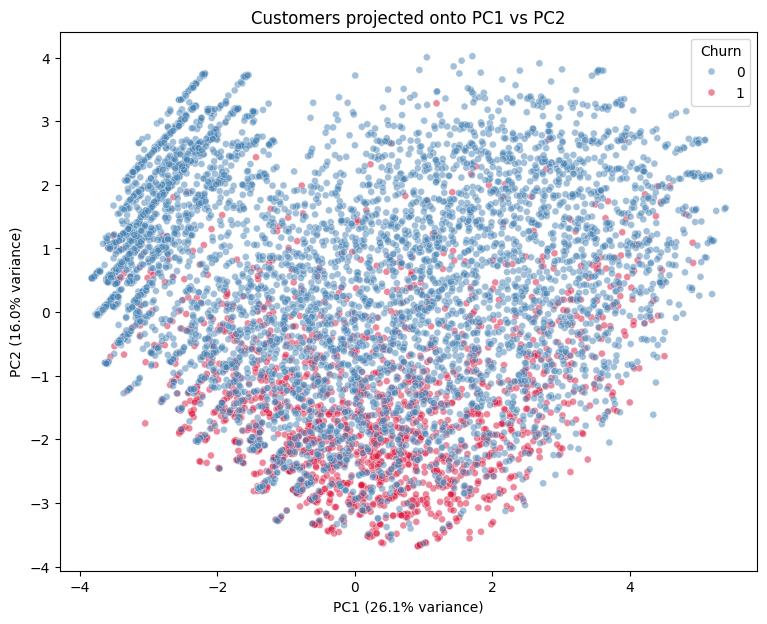

In [ ]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=X_pca_df['PC1'], y=X_pca_df['PC2'],
    hue=y.values, palette={0: 'steelblue', 1: 'crimson'},
    alpha=0.5, s=25
)
plt.title('Customers projected onto PC1 vs PC2')
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
plt.legend(title='Churn')
plt.show()

### 8.3 What each component is made of (loadings)


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_selected.columns,
    columns=pca_cols
)

# Top contributing original features for PC1 and PC2
print("Top drivers of PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop drivers of PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Top drivers of PC1:
remainder__Monthly Charges       0.402514
remainder__Total Charges         0.389489
nominal__Streaming Movies_Yes    0.306155
nominal__Streaming TV_Yes        0.305576
nominal__Internet Service_No     0.299784
Name: PC1, dtype: float64

Top drivers of PC2:
ordinal__Contract                           0.450773
remainder__Tenure Months                    0.360752
nominal__Payment Method_Electronic check    0.359891
nominal__Internet Service_Fiber optic       0.311409
binary__Dependents                          0.240382
Name: PC2, dtype: float64


#Assignment 2


## 9. Linear Regression Implementation

Linear regression is a linear model that assumes a linear relationship between the input features (X) and a continuous target variable (y). While churn is a binary outcome (0 or 1), we can still apply linear regression to demonstrate the concept. However, it's important to understand that the output of linear regression in this context will be a continuous value, which we'd typically need to threshold to get a binary prediction. For actual classification, logistic regression is usually preferred.

Here, we'll perform the following steps:
1.  **Split the data** into training and testing sets.
2.  **Train a Linear Regression model** on the training data.
3.  **Evaluate the model** using relevant metrics for regression.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the data into training and testing sets
# We'll use X_pca_df (PCA-transformed features) and y (Churn Value)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_df, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 13)
X_test shape: (1409, 13)
y_train shape: (5634,)
y_test shape: (1409,)


In [ ]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Display first few actual vs predicted values
results_df = pd.DataFrame({'Actual Churn Value': y_test, 'Predicted Churn Value (Continuous)': y_pred})
results_df['Predicted Churn (Binary, threshold=0.5)'] = (y_pred > 0.5).astype(int)
display(results_df.head())

print("\nInterpretation:")
print("  - MSE measures the average squared difference between actual and predicted values. Lower is better.")
print("  - R2 score indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. Higher is better (closer to 1).")
print("  - For a binary target like churn, these metrics are less intuitive than classification metrics (e.g., accuracy, precision, recall) that would be used with logistic regression.")
print("  - The 'Predicted Churn Value (Continuous)' can be interpreted as a probability-like score, and a threshold (e.g., 0.5) can be applied to convert it to a binary prediction.")

Mean Squared Error (MSE): 0.1448
R-squared (R2) Score: 0.2876


,Actual Churn Value,Predicted Churn Value (Continuous),"Predicted Churn (Binary, threshold=0.5)"
185,1,0.498613,0
2715,0,0.282959,0
3825,0,0.306441,0
1807,1,0.627448,1
132,1,0.397118,0



Interpretation:
  - MSE measures the average squared difference between actual and predicted values. Lower is better.
  - R2 score indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. Higher is better (closer to 1).
  - For a binary target like churn, these metrics are less intuitive than classification metrics (e.g., accuracy, precision, recall) that would be used with logistic regression.
  - The 'Predicted Churn Value (Continuous)' can be interpreted as a probability-like score, and a threshold (e.g., 0.5) can be applied to convert it to a binary prediction.


## 10. Linear Regression Visualizations

Let's visualize the results of the linear regression model. While linear regression is typically used for continuous target variables, we can still use these plots to understand the model's behavior on our binary churn data. It's important to remember that the model is trying to fit a line to 0s and 1s, so the plots might look different than for a continuous target.

### 10.1 Residual Plot

A residual plot displays the difference between the observed values (actual churn) and the predicted values (model's continuous output). For a good linear regression model, residuals should be randomly scattered around zero, indicating that the model captures the underlying pattern well and that the variance of the errors is constant (homoscedasticity).

In our case, since the actual values are only 0 or 1, the residuals will form two distinct bands. The goal is to see if the predictions are somewhat centered between these bands, and if there's any clear pattern that the model is missing.

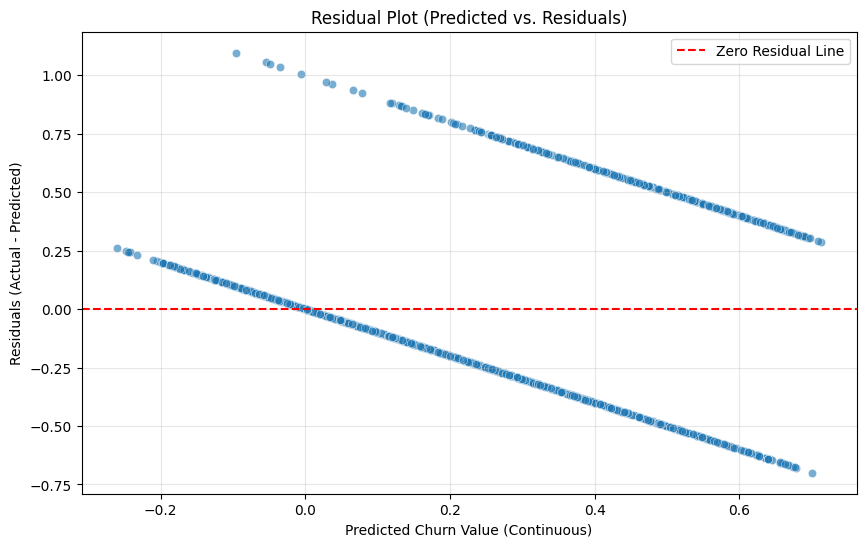

Interpretation:
  - For a binary target, residuals tend to form distinct bands.
  - A good model would have residuals centered around zero, but for binary classification, this often looks like two 'clouds' of points.
  - We're looking for an absence of strong patterns (e.g., a curve, a fanning out) which would suggest violated assumptions or missed relationships.


In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residual Line')
plt.title('Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Churn Value (Continuous)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Interpretation:")
print("  - For a binary target, residuals tend to form distinct bands.")
print("  - A good model would have residuals centered around zero, but for binary classification, this often looks like two 'clouds' of points.")
print("  - We're looking for an absence of strong patterns (e.g., a curve, a fanning out) which would suggest violated assumptions or missed relationships.")

### 10.2 Predicted vs. Actual Values Plot

This plot directly compares the model's continuous predictions against the actual binary churn values. Ideally, for a perfect prediction, all points would lie on the y=x line. For binary classification, we expect to see points clustered around y=0 for non-churners and y=1 for churners, with the model's predictions showing a continuous range that ideally separates these two groups.

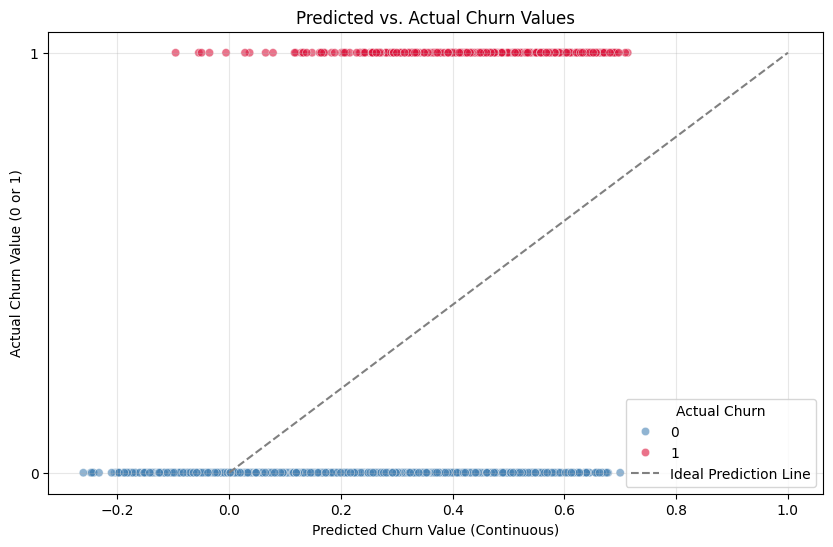

Interpretation:
  - This plot shows how well the continuous predictions align with the actual binary outcomes.
  - Points near the bottom-left represent non-churners (0) correctly predicted with low scores.
  - Points near the top-right represent churners (1) correctly predicted with high scores.
  - The spread of points between 0 and 1 indicates the model's uncertainty or difficulty in distinguishing between churners and non-churners.


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=y_test, alpha=0.6, hue=y_test, palette={0: 'steelblue', 1: 'crimson'})
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Ideal Prediction Line') # Add ideal line if y is also continuous
plt.title('Predicted vs. Actual Churn Values')
plt.xlabel('Predicted Churn Value (Continuous)')
plt.ylabel('Actual Churn Value (0 or 1)')
plt.yticks([0, 1]) # Set y-axis ticks to only 0 and 1
plt.legend(title='Actual Churn')
plt.grid(alpha=0.3)
plt.show()

print("Interpretation:")
print("  - This plot shows how well the continuous predictions align with the actual binary outcomes.")
print("  - Points near the bottom-left represent non-churners (0) correctly predicted with low scores.")
print("  - Points near the top-right represent churners (1) correctly predicted with high scores.")
print("  - The spread of points between 0 and 1 indicates the model's uncertainty or difficulty in distinguishing between churners and non-churners.")

## 11. Predicting 'Churn Score' with Linear Regression

Since 'Churn Score' is a continuous numerical variable, linear regression is a more directly applicable model. We'll use the same PCA-transformed features (`X_pca_df`) and set 'Churn Score' as our target (`y_churn_score`).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set 'Churn Score' as the new target variable (get from encoded_df)
y_churn_score = encoded_df['remainder__Churn Score']

# Split the data using X_pca_df (PCA-transformed features) and y_churn_score
X_train_cs, X_test_cs, y_train_cs, y_test_cs = train_test_split(
    X_pca_df, y_churn_score, test_size=0.2, random_state=42
)

# Initialize and train the Linear Regression model
linear_model_cs = LinearRegression()
linear_model_cs.fit(X_train_cs, y_train_cs)

# Make predictions on the test set
y_pred_cs = linear_model_cs.predict(X_test_cs)

# Evaluate the model
mse_cs = mean_squared_error(y_test_cs, y_pred_cs)
r2_cs = r2_score(y_test_cs, y_pred_cs)

print(f"Linear Regression for Churn Score:")
print(f"  Mean Squared Error (MSE): {mse_cs:.4f}")
print(f"  R-squared (R2) Score: {r2_cs:.4f}")

# Display first few actual vs predicted values
results_df_cs = pd.DataFrame({'Actual Churn Score': y_test_cs, 'Predicted Churn Score': y_pred_cs})
display(results_df_cs.head())

Linear Regression for Churn Score:
  Mean Squared Error (MSE): 392.4406
  R-squared (R2) Score: 0.1145


,Actual Churn Score,Predicted Churn Score
185,96,66.505846
2715,59,59.468692
3825,39,59.947565
1807,72,70.272285
132,88,63.583020


The current linear and polynomial regression models yield low R2 scores for 'Churn Score' (0.11). This indicates they explain only a small fraction of the target variability, suggesting more complex, non-linear relationships or insufficient features. Increasing polynomial degree might improve training fit but risks significant overfitting, highlighting the need for more advanced regression techniques or richer features to capture the full complexity of customer behavior.

#Assignment 3


## 12. Regularization for 'Churn Score' Prediction

Given the low R-squared score we observed with standard Linear Regression for 'Churn Score', and the potential for multicollinearity in our feature set (even after PCA, though PCA aims to mitigate this, the components themselves are combinations of features), regularization techniques like Ridge and Lasso can be beneficial.

### What is Regularization?

Regularization methods add a penalty term to the loss function during model training. This penalty discourages complex models and helps prevent overfitting, especially when dealing with many features or highly correlated predictors.

*   **Ridge Regression (L2 Regularization)**: Adds a penalty proportional to the square of the magnitude of coefficients. It shrinks coefficients towards zero but rarely makes them exactly zero. This helps in reducing the impact of less important features and is effective in handling multicollinearity.
*   **Lasso Regression (L1 Regularization)**: Adds a penalty proportional to the absolute value of the magnitude of coefficients. It can shrink some coefficients exactly to zero, effectively performing feature selection and yielding sparser models. This is useful when you suspect many features are irrelevant.

### 12.1 Ridge Regression for 'Churn Score'

We'll use `Ridge` from `sklearn.linear_model`. The `alpha` parameter controls the strength of the regularization; a higher `alpha` means a stronger penalty.

In [ ]:
from sklearn.linear_model import Ridge

# We'll re-use the split data for Churn Score from the previous linear regression
# X_train_cs, X_test_cs, y_train_cs, y_test_cs are already defined.

# Initialize and train the Ridge Regression model
# Let's start with an alpha (regularization strength) of 1.0
ridge_model_cs = Ridge(alpha=1.0, random_state=42)
ridge_model_cs.fit(X_train_cs, y_train_cs)

# Make predictions on the test set
y_pred_ridge_cs = ridge_model_cs.predict(X_test_cs)

# Evaluate the model
mse_ridge_cs = mean_squared_error(y_test_cs, y_pred_ridge_cs)
r2_ridge_cs = r2_score(y_test_cs, y_pred_ridge_cs)

print(f"Ridge Regression for Churn Score (alpha=1.0):")
print(f"  Mean Squared Error (MSE): {mse_ridge_cs:.4f}")
print(f"  R-squared (R2) Score: {r2_ridge_cs:.4f}")

# Display first few actual vs predicted values
results_df_ridge_cs = pd.DataFrame({'Actual Churn Score': y_test_cs, 'Predicted Churn Score (Ridge)': y_pred_ridge_cs})
display(results_df_ridge_cs.head())

Ridge Regression for Churn Score (alpha=1.0):
  Mean Squared Error (MSE): 392.4403
  R-squared (R2) Score: 0.1145


,Actual Churn Score,Predicted Churn Score (Ridge)
185,96,66.505329
2715,59,59.467994
3825,39,59.947510
1807,72,70.271523
132,88,63.582438


### 12.2 Lasso Regression for 'Churn Score'

Now, let's apply Lasso Regression. Lasso can set some coefficients to exactly zero, which means it effectively performs feature selection. We'll again use `alpha=1.0` initially.

In [ ]:
from sklearn.linear_model import Lasso

# Initialize and train the Lasso Regression model
# Set max_iter for convergence, especially with scaled data
lasso_model_cs = Lasso(alpha=1.0, random_state=42, max_iter=2000)
lasso_model_cs.fit(X_train_cs, y_train_cs)

# Make predictions on the test set
y_pred_lasso_cs = lasso_model_cs.predict(X_test_cs)

# Evaluate the model
mse_lasso_cs = mean_squared_error(y_test_cs, y_pred_lasso_cs)
r2_lasso_cs = r2_score(y_test_cs, y_pred_lasso_cs)

print(f"Lasso Regression for Churn Score (alpha=1.0):")
print(f"  Mean Squared Error (MSE): {mse_lasso_cs:.4f}")
print(f"  R-squared (R2) Score: {r2_lasso_cs:.4f}")

# Display first few actual vs predicted values
results_df_lasso_cs = pd.DataFrame({'Actual Churn Score': y_test_cs, 'Predicted Churn Score (Lasso)': y_pred_lasso_cs})
display(results_df_lasso_cs.head())

Lasso Regression for Churn Score (alpha=1.0):
  Mean Squared Error (MSE): 394.1585
  R-squared (R2) Score: 0.1106


,Actual Churn Score,Predicted Churn Score (Lasso)
185,96,65.537075
2715,59,56.151406
3825,39,60.391522
1807,72,69.320242
132,88,61.560721


### 12.3 Comparing Coefficients and Interpretation

Let's compare the coefficients learned by the standard Linear Regression, Ridge, and Lasso models. This can give us insights into how regularization affects feature importance and model sparsity.

In [ ]:
feature_names = X_pca_df.columns

# Create a DataFrame to hold coefficients for comparison
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Reg Coeff': linear_model_cs.coef_,
    'Ridge Coeff': ridge_model_cs.coef_,
    'Lasso Coeff': lasso_model_cs.coef_
})

# Sort by absolute Lasso coefficient to see which features were most impacted or zeroed out
coef_df['Abs Lasso Coeff'] = np.abs(coef_df['Lasso Coeff'])
display(coef_df.sort_values(by='Abs Lasso Coeff', ascending=False).round(4))

print("\nObservations:")
print("  - Ridge Regression tends to shrink coefficients but keeps most of them non-zero.")
print("  - Lasso Regression often drives some coefficients exactly to zero, effectively performing feature selection. Features with zero coefficients are considered less important by the Lasso model.")
print("  - The R2 scores for both Ridge and Lasso are similar to the base Linear Regression in this case, suggesting that for this specific dataset and PCA-transformed features, the chosen alpha might not have dramatically changed the overall predictive power, or perhaps the problem is inherently complex for these linear models.")
print("  - Tuning the 'alpha' parameter (e.g., using GridSearchCV or RandomizedSearchCV) can further optimize these models.")

,Feature,Linear Reg Coeff,Ridge Coeff,Lasso Coeff,Abs Lasso Coeff
1,PC2,-4.3005,-4.3003,-3.964,3.964
0,PC1,0.1449,0.1449,0.000,0.000
2,PC3,0.1995,0.1994,0.000,0.000
3,PC4,0.8140,0.8139,0.000,0.000
4,PC5,-0.0977,-0.0977,-0.000,0.000
5,PC6,0.8307,0.8306,0.000,0.000
6,PC7,-0.4669,-0.4668,-0.000,0.000
7,PC8,0.0558,0.0558,0.000,0.000
8,PC9,-0.3448,-0.3447,-0.000,0.000
9,PC10,-0.1268,-0.1268,-0.000,0.000



Observations:
  - Ridge Regression tends to shrink coefficients but keeps most of them non-zero.
  - Lasso Regression often drives some coefficients exactly to zero, effectively performing feature selection. Features with zero coefficients are considered less important by the Lasso model.
  - The R2 scores for both Ridge and Lasso are similar to the base Linear Regression in this case, suggesting that for this specific dataset and PCA-transformed features, the chosen alpha might not have dramatically changed the overall predictive power, or perhaps the problem is inherently complex for these linear models.
  - Tuning the 'alpha' parameter (e.g., using GridSearchCV or RandomizedSearchCV) can further optimize these models.
